# Final Model Audit

Review persisted, labeled evidence only. This notebook never trains, loads a
model, generates predictions, or accesses the network.

In [1]:
# ruff: noqa: E402, E501
# pyright: reportUnusedExpression=false
prediction_log_path = None
artifact_manifest_path = None
probe_predictions_path = None
stress_probe_predictions_path = None
shortcut_probe_predictions_path = None
stored_attributions_path = None
candidate_id = None
tokenizer_id = None
checkpoint_id = None
evaluation_split = "validation"

## Setup and Artifact Inventory

Import libraries, resolve artifact paths, define shared diagnostics helpers, and display the persisted-artifact inventory.

In [2]:
# ruff: noqa: E501
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = next(
    (
        parent
        for parent in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
        if (parent / "pyproject.toml").is_file()
    ),
    Path.cwd().resolve(),
)
RESULTS_DIR = PROJECT_ROOT / "results"

ARTIFACT_DEFAULTS = {
    "prediction_log": "prediction_log.csv",
    "artifact_manifest": "artifact_manifest.json",
    "probe_predictions": "probe_predictions.csv",
    "stress_probe_predictions": "stress_probe_predictions.csv",
    "shortcut_probe_predictions": "shortcut_probe_predictions.csv",
    "stored_attributions": "stored_attributions.csv",
}
ARTIFACT_PARAMETERS = {
    "prediction_log": prediction_log_path,
    "artifact_manifest": artifact_manifest_path,
    "probe_predictions": probe_predictions_path,
    "stress_probe_predictions": stress_probe_predictions_path,
    "shortcut_probe_predictions": shortcut_probe_predictions_path,
    "stored_attributions": stored_attributions_path,
}


def resolve_artifact_path(name: str) -> Path:
    configured_path = ARTIFACT_PARAMETERS[name]
    return (
        Path(configured_path)
        if configured_path is not None
        else RESULTS_DIR / ARTIFACT_DEFAULTS[name]
    )


ARTIFACT_PATHS = {name: resolve_artifact_path(name) for name in ARTIFACT_DEFAULTS}


def needs_new_evidence(section: str, requirement: str, detail: str) -> pd.DataFrame:
    return pd.DataFrame(
        [
            {
                "section": section,
                "evidence_status": "needs-new-evidence",
                "requirement": requirement,
                "detail": detail,
            }
        ]
    )


def read_csv_or_diagnostic(name: str) -> tuple[pd.DataFrame | None, str | None]:
    path = ARTIFACT_PATHS[name]
    if not path.is_file():
        return None, f"needs-new-evidence: missing {name}: {path}"
    try:
        return pd.read_csv(path), None
    except (OSError, pd.errors.EmptyDataError, pd.errors.ParserError) as error:
        return None, f"needs-new-evidence: unreadable {name}: {path}: {error}"


def read_manifest_or_diagnostic() -> tuple[dict[str, object] | None, str | None]:
    path = ARTIFACT_PATHS["artifact_manifest"]
    if not path.is_file():
        return None, f"needs-new-evidence: missing artifact_manifest: {path}"
    try:
        loaded_manifest = json.loads(path.read_text(encoding="utf-8"))
    except (OSError, json.JSONDecodeError) as error:
        return None, f"needs-new-evidence: invalid artifact_manifest: {path}: {error}"
    if not isinstance(loaded_manifest, dict):
        return (
            None,
            f"needs-new-evidence: artifact_manifest must be a JSON object: {path}",
        )
    return loaded_manifest, None


manifest, manifest_diagnostic = read_manifest_or_diagnostic()
artifact_inventory = pd.DataFrame(
    [
        {
            "artifact": name,
            "path": str(path.relative_to(PROJECT_ROOT))
            if path.is_relative_to(PROJECT_ROOT)
            else str(path),
            "exists": path.is_file(),
            "status": "available" if path.is_file() else "needs-new-evidence",
            "release_required": True,
        }
        for name, path in ARTIFACT_PATHS.items()
    ]
)
display(artifact_inventory)

,artifact,path,exists,status,release_required
0,prediction_log,results/prediction_log.csv,True,available,True
1,artifact_manifest,results/artifact_manifest.json,True,available,True
2,probe_predictions,results/probe_predictions.csv,True,available,True
3,stress_probe_predictions,results/stress_probe_predictions.csv,True,available,True
4,shortcut_probe_predictions,results/shortcut_probe_predictions.csv,True,available,True
5,stored_attributions,results/stored_attributions.csv,True,available,True


## 0. Audit Contract and Frozen Candidate

Establish whether persisted artifacts identify one candidate and its evaluation split.

In [3]:
identity_columns = ("candidate_id", "tokenizer_id", "checkpoint_id")
prediction_log_raw, prediction_log_diagnostic = read_csv_or_diagnostic("prediction_log")
if prediction_log_raw is None:
    contract_evidence = needs_new_evidence(
        "audit_contract",
        "labeled prediction_log",
        prediction_log_diagnostic or "needs-new-evidence",
    )
else:
    present_identity_columns = [
        column for column in identity_columns if column in prediction_log_raw.columns
    ]
    contract_evidence = pd.DataFrame(
        [
            {
                "evidence_status": "available"
                if len(present_identity_columns) == len(identity_columns)
                else "needs-new-evidence",
                "rows": len(prediction_log_raw),
                "identity_columns_present": len(present_identity_columns),
                "manifest_status": "available"
                if manifest_diagnostic is None
                else manifest_diagnostic,
            }
        ]
    )
display(contract_evidence)

,evidence_status,rows,identity_columns_present,manifest_status
0,available,14814,3,available


### Audit Contract Decision

**Observation:** The preceding contract evidence reports whether the persisted prediction log and candidate identifiers are available.

**Interpretation:** A frozen-candidate claim is supported only when the displayed identity fields and manifest status are available.

**Action:** Use the displayed missing requirement to persist or bind the evidence before treating later metrics as a final audit.

## 1. Load Prediction, Split, and Model Artifacts

Validate only an existing prediction log; no model artifact is loaded for inference.

In [4]:
def validate_prediction_log(
    prediction_log: pd.DataFrame,
    candidate_id: str | None,
    tokenizer_id: str | None,
    checkpoint_id: str | None,
    evaluation_split: str = "validation",
) -> pd.DataFrame:
    audit_identity = {
        "candidate_id": candidate_id,
        "tokenizer_id": tokenizer_id,
        "checkpoint_id": checkpoint_id,
    }
    required_columns = {
        "id",
        "split",
        "y_true",
        "y_pred",
        "search_term",
        "product_title",
        "product_description",
    } | set(audit_identity)
    missing_columns = required_columns - set(prediction_log.columns)
    if missing_columns:
        raise ValueError(
            f"Prediction log is missing columns: {sorted(missing_columns)}"
        )
    if not isinstance(evaluation_split, str) or evaluation_split not in {
        "validation",
        "holdout",
        "test",
    }:
        raise ValueError(
            "evaluation_split must be one of: validation, holdout, or test."
        )
    if not bool(prediction_log["id"].notna().all()):
        raise ValueError("id must not contain null values.")
    if bool(prediction_log["id"].duplicated().any()):
        raise ValueError("id values must be unique for final evaluation.")
    for column, value in audit_identity.items():
        if not isinstance(value, str) or not value.strip():
            raise ValueError(f"{column} parameter must be a non-empty string.")
        if not bool(prediction_log[column].notna().all()) or not bool(
            prediction_log[column].eq(value).all()
        ):
            raise ValueError(
                f"Prediction log {column} must equal supplied parameter {value!r} for every row."
            )
    if not bool(prediction_log["y_true"].notna().all()):
        raise ValueError("y_true is required; refusing an unlabeled Kaggle submission.")
    for column in ("y_true", "y_pred"):
        values = prediction_log[column]
        if not pd.api.types.is_numeric_dtype(values) or not bool(values.notna().all()):
            raise ValueError(f"{column} must be numeric and non-null.")
        if bool(values.isin((float("inf"), float("-inf"))).any()):
            raise ValueError(f"{column} must contain only finite values.")
    if not bool(prediction_log["y_true"].between(1.0, 3.0).all()):
        raise ValueError(
            "y_true values must be in [1.0, 3.0]; refusing an unlabeled Kaggle submission."
        )
    if not bool(prediction_log["split"].notna().all()) or bool(
        prediction_log["split"].astype(str).str.strip().eq("").any()
    ):
        raise ValueError("split must not contain blank values.")
    if not bool(prediction_log["split"].eq(evaluation_split).all()):
        raise ValueError(
            f"prediction log rows must all match evaluation_split {evaluation_split!r}."
        )
    for column in ("search_term", "product_title", "product_description"):
        non_null_values = prediction_log[column].dropna()
        if not bool(non_null_values.map(lambda value: isinstance(value, str)).all()):
            raise ValueError(f"{column} must contain only string values.")
    for column in ("search_term", "product_title"):
        if not bool(prediction_log[column].notna().all()) or bool(
            prediction_log[column].astype(str).str.strip().eq("").any()
        ):
            raise ValueError(f"{column} must contain non-blank text.")
    prediction_log = prediction_log.copy()
    prediction_log["product_description"] = prediction_log[
        "product_description"
    ].fillna("")
    return prediction_log


prediction_log = None
inferred_identity: dict[str, str | None] = dict.fromkeys(identity_columns)
if prediction_log_raw is None:
    load_evidence = needs_new_evidence(
        "artifact_load",
        "prediction_log",
        prediction_log_diagnostic or "needs-new-evidence",
    )
else:
    inferred_identity = {
        column: candidate_id
        if column == "candidate_id"
        else tokenizer_id
        if column == "tokenizer_id"
        else checkpoint_id
        for column in identity_columns
    }
    for column in identity_columns:
        values = (
            prediction_log_raw[column]
            if column in prediction_log_raw.columns
            else pd.Series(dtype="object")
        )
        if inferred_identity[column] is None and values.nunique(dropna=True) == 1:
            inferred_identity[column] = str(values.dropna().iloc[0])
    try:
        prediction_log = validate_prediction_log(
            prediction_log_raw, evaluation_split=evaluation_split, **inferred_identity
        )
        load_evidence = pd.DataFrame(
            [
                {
                    "evidence_status": "available",
                    "rows": len(prediction_log),
                    "split": evaluation_split,
                    **inferred_identity,
                }
            ]
        )
    except ValueError as error:
        load_evidence = needs_new_evidence(
            "artifact_load",
            "valid labeled prediction_log",
            f"needs-new-evidence: {error}",
        )
display(load_evidence)

,evidence_status,rows,split,candidate_id,tokenizer_id,checkpoint_id
0,available,14814,validation,tfidf-svd-all-text_ridge_seed42,tfidf-svd-057a8215c4c0,ridge-178e1eb6e6be


### Prediction Log Contract Decision

**Observation:** The preceding load evidence records whether the stored log passed its labeled, split, and identity contract.

**Interpretation:** Only a displayed `available` contract permits the downstream metrics to use those persisted rows.

**Action:** Correct the displayed contract gap in the stored artifact instead of generating replacement predictions in this notebook.

## 2. Final Performance and Uncertainty

Calculate performance from validated labeled predictions when they are available.

In [5]:
if prediction_log is None:
    performance_evidence = needs_new_evidence(
        "performance",
        "validated labeled prediction_log",
        "needs-new-evidence: performance metrics require the Section 1 contract",
    )
else:
    residual = prediction_log["y_true"] - prediction_log["y_pred"]
    performance_evidence = pd.DataFrame(
        [
            {
                "evidence_status": "available",
                "rows": len(prediction_log),
                "mae": residual.abs().mean(),
                "rmse": (residual.pow(2).mean()) ** 0.5,
                "mean_residual": residual.mean(),
            }
        ]
    )
display(performance_evidence)

,evidence_status,rows,mae,rmse,mean_residual
0,available,14814,0.426674,0.52069,-0.001902


Visualize the validated labeled predictions: predicted-versus-actual density,
the residual distribution, and a seeded bootstrap RMSE distribution that puts
an uncertainty interval around the point metric. Skipped until the Section 1
contract passes.

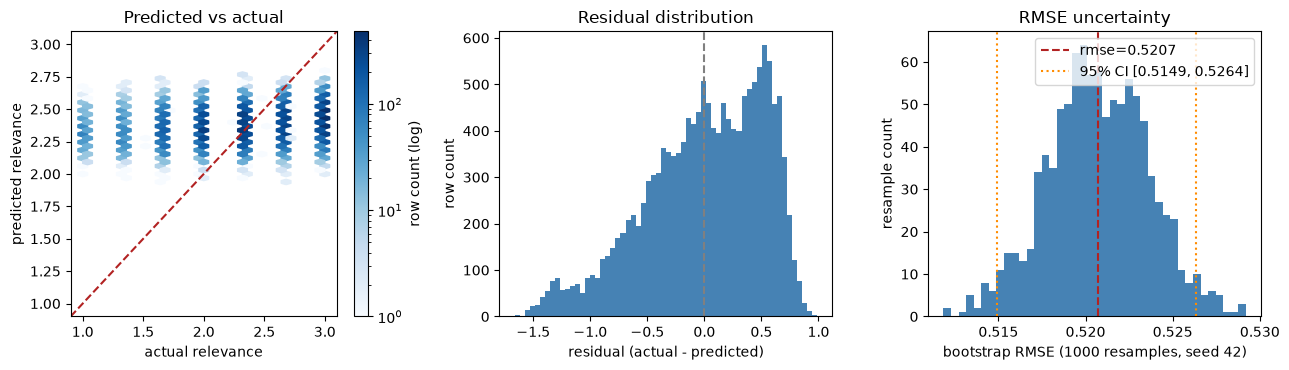

In [6]:
if prediction_log is None:
    print("needs-new-evidence: performance plots require the Section 1 contract")
else:
    residual = prediction_log["y_true"] - prediction_log["y_pred"]
    squared_errors = residual.pow(2).to_numpy()
    bootstrap_rng = np.random.default_rng(42)
    bootstrap_rmse = np.array(
        [
            float(
                np.sqrt(
                    squared_errors[
                        bootstrap_rng.integers(
                            0, len(squared_errors), len(squared_errors)
                        )
                    ].mean()
                )
            )
            for _ in range(1000)
        ]
    )
    rmse_point = float(np.sqrt(squared_errors.mean()))
    rmse_low, rmse_high = np.percentile(bootstrap_rmse, [2.5, 97.5])
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
    density = axes[0].hexbin(
        prediction_log["y_true"],
        prediction_log["y_pred"],
        gridsize=25,
        bins="log",
        mincnt=1,
        cmap="Blues",
    )
    axes[0].axline((1.0, 1.0), (3.0, 3.0), color="firebrick", linestyle="--")
    axes[0].set_xlabel("actual relevance")
    axes[0].set_ylabel("predicted relevance")
    axes[0].set_title("Predicted vs actual")
    fig.colorbar(density, ax=axes[0], label="row count (log)")
    axes[1].hist(residual, bins=60, color="steelblue")
    axes[1].axvline(0.0, color="gray", linestyle="--")
    axes[1].set_xlabel("residual (actual - predicted)")
    axes[1].set_ylabel("row count")
    axes[1].set_title("Residual distribution")
    axes[2].hist(bootstrap_rmse, bins=40, color="steelblue")
    axes[2].axvline(
        rmse_point, color="firebrick", linestyle="--", label=f"rmse={rmse_point:.4f}"
    )
    axes[2].axvline(
        rmse_low,
        color="darkorange",
        linestyle=":",
        label=f"95% CI [{rmse_low:.4f}, {rmse_high:.4f}]",
    )
    axes[2].axvline(rmse_high, color="darkorange", linestyle=":")
    axes[2].set_xlabel("bootstrap RMSE (1000 resamples, seed 42)")
    axes[2].set_ylabel("resample count")
    axes[2].set_title("RMSE uncertainty")
    axes[2].legend()
    fig.tight_layout()
    plt.show()

### Final Performance Decision

**Observation:** The preceding performance evidence contains real MAE, RMSE, and residual statistics only when the labeled-log contract passed.

**Interpretation:** The displayed row count defines the persisted evaluation evidence behind every reported metric.

**Action:** Use the displayed diagnostic to obtain labels or use the displayed metrics in the final release review.

## 3. Robustness Tests

Summarize persisted baseline-versus-probe prediction deltas without creating probe inputs or running inference.

In [7]:
probe_predictions, probe_diagnostic = read_csv_or_diagnostic("probe_predictions")
if probe_predictions is None:
    robustness_evidence = needs_new_evidence(
        "robustness", "probe_predictions", probe_diagnostic or "needs-new-evidence"
    )
else:
    required_probe_columns = {
        "id",
        "scenario",
        "baseline_prediction",
        "probe_prediction",
    }
    missing_probe_columns = required_probe_columns - set(probe_predictions.columns)
    if missing_probe_columns:
        robustness_evidence = needs_new_evidence(
            "robustness",
            "paired probe predictions",
            f"needs-new-evidence: missing columns {sorted(missing_probe_columns)}",
        )
    else:
        probe_delta = (
            probe_predictions["probe_prediction"]
            - probe_predictions["baseline_prediction"]
        ).abs()
        robustness_evidence = (
            probe_predictions.assign(absolute_prediction_delta=probe_delta)
            .groupby("scenario", dropna=False)
            .agg(
                rows=("id", "size"),
                mean_absolute_prediction_delta=("absolute_prediction_delta", "mean"),
                max_absolute_prediction_delta=("absolute_prediction_delta", "max"),
            )
            .reset_index()
            .assign(evidence_status="available")
        )
display(robustness_evidence)

,scenario,rows,mean_absolute_prediction_delta,max_absolute_prediction_delta,evidence_status
0,doubled_whitespace_description,14814,0.000000,0.000000,available
1,typo_title,14814,0.002067,0.043833,available
2,uppercase_title,14814,0.000000,0.000000,available


Visualize the per-scenario |probe - baseline| prediction-delta distributions;
the summary table above reports only mean and max, while the boxplot exposes
each scenario's tail. The same helper is reused by the stress and shortcut
sections, which persist the same paired schema.

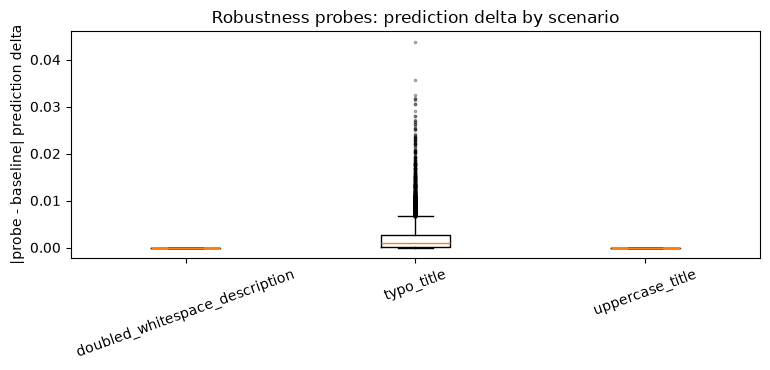

In [8]:
def plot_scenario_prediction_deltas(
    paired_predictions: pd.DataFrame, title: str
) -> None:
    delta_frame = paired_predictions.assign(
        absolute_prediction_delta=(
            paired_predictions["probe_prediction"]
            - paired_predictions["baseline_prediction"]
        ).abs()
    )
    scenarios = sorted(delta_frame["scenario"].astype(str).unique())
    delta_groups = [
        delta_frame.loc[
            delta_frame["scenario"].astype(str).eq(scenario),
            "absolute_prediction_delta",
        ].to_numpy()
        for scenario in scenarios
    ]
    fig, ax = plt.subplots(figsize=(max(6.0, 1.6 * len(scenarios) + 3.0), 3.8))
    ax.boxplot(
        delta_groups,
        tick_labels=scenarios,
        flierprops={"marker": ".", "markersize": 3, "alpha": 0.4},
    )
    ax.set_ylabel("|probe - baseline| prediction delta")
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=20)
    fig.tight_layout()
    plt.show()


if robustness_evidence["evidence_status"].eq("available").all():
    plot_scenario_prediction_deltas(
        probe_predictions, "Robustness probes: prediction delta by scenario"
    )
else:
    print(
        "needs-new-evidence: robustness delta plot requires persisted paired "
        "probe predictions"
    )

### Robustness Evidence Decision

**Observation:** The preceding robustness table reports persisted paired prediction deltas by scenario, or its precise evidence gap.

**Interpretation:** A scenario is measured only when the displayed table contains stored baseline and probe predictions.

**Action:** Persist the missing paired outputs identified above before making an invariance claim.

## 4. Stress Tests

Summarize persisted long-text, empty-description, or other stress predictions without generating them.

In [9]:
stress_predictions, stress_diagnostic = read_csv_or_diagnostic(
    "stress_probe_predictions"
)
if stress_predictions is None:
    stress_evidence = needs_new_evidence(
        "stress", "stress_probe_predictions", stress_diagnostic or "needs-new-evidence"
    )
else:
    required_stress_columns = {
        "id",
        "scenario",
        "baseline_prediction",
        "probe_prediction",
    }
    missing_stress_columns = required_stress_columns - set(stress_predictions.columns)
    if missing_stress_columns:
        stress_evidence = needs_new_evidence(
            "stress",
            "paired stress predictions",
            f"needs-new-evidence: missing columns {sorted(missing_stress_columns)}",
        )
    else:
        stress_evidence = (
            stress_predictions.assign(
                absolute_prediction_delta=(
                    stress_predictions["probe_prediction"]
                    - stress_predictions["baseline_prediction"]
                ).abs()
            )
            .groupby("scenario", dropna=False)
            .agg(
                rows=("id", "size"),
                mean_absolute_prediction_delta=("absolute_prediction_delta", "mean"),
                max_absolute_prediction_delta=("absolute_prediction_delta", "max"),
            )
            .reset_index()
            .assign(evidence_status="available")
        )
display(stress_evidence)

,scenario,rows,mean_absolute_prediction_delta,max_absolute_prediction_delta,evidence_status
0,empty_description,14814,0.060018,0.317245,available
1,tiled_long_description,14814,0.048133,0.181122,available


Visualize the per-scenario stress prediction-delta distributions with the
shared scenario-delta helper. Skipped until paired stress predictions are
persisted.

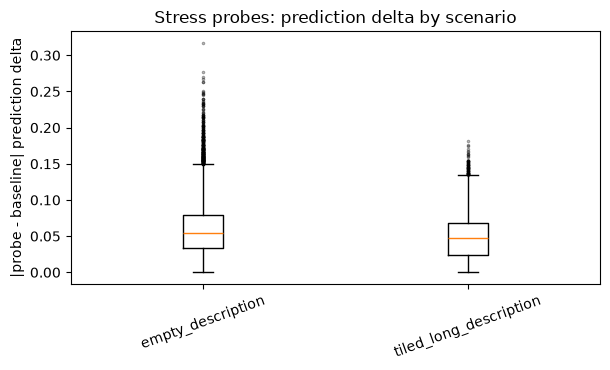

In [10]:
if stress_evidence["evidence_status"].eq("available").all():
    plot_scenario_prediction_deltas(
        stress_predictions, "Stress probes: prediction delta by scenario"
    )
else:
    print(
        "needs-new-evidence: stress delta plot requires persisted paired "
        "stress predictions"
    )

### Stress Evidence Decision

**Observation:** The preceding stress table is populated from stored stress predictions or names the missing persisted evidence.

**Interpretation:** Stress resilience is supported only by the displayed scenario-level prediction deltas.

**Action:** Produce the missing artifact outside this audit, then rerun the notebook to inspect the resulting table.

## 5. Adversarial / Shortcut Tests

Summarize persisted shortcut-test prediction deltas without constructing adversarial templates.

In [11]:
shortcut_predictions, shortcut_diagnostic = read_csv_or_diagnostic(
    "shortcut_probe_predictions"
)
if shortcut_predictions is None:
    shortcut_evidence = needs_new_evidence(
        "shortcut_tests",
        "shortcut_probe_predictions",
        shortcut_diagnostic or "needs-new-evidence",
    )
else:
    required_shortcut_columns = {
        "id",
        "scenario",
        "baseline_prediction",
        "probe_prediction",
    }
    missing_shortcut_columns = required_shortcut_columns - set(
        shortcut_predictions.columns
    )
    if missing_shortcut_columns:
        shortcut_evidence = needs_new_evidence(
            "shortcut_tests",
            "paired shortcut predictions",
            f"needs-new-evidence: missing columns {sorted(missing_shortcut_columns)}",
        )
    else:
        shortcut_evidence = (
            shortcut_predictions.assign(
                absolute_prediction_delta=(
                    shortcut_predictions["probe_prediction"]
                    - shortcut_predictions["baseline_prediction"]
                ).abs()
            )
            .groupby("scenario", dropna=False)
            .agg(
                rows=("id", "size"),
                mean_absolute_prediction_delta=("absolute_prediction_delta", "mean"),
                max_absolute_prediction_delta=("absolute_prediction_delta", "max"),
            )
            .reset_index()
            .assign(evidence_status="available")
        )
display(shortcut_evidence)

,scenario,rows,mean_absolute_prediction_delta,max_absolute_prediction_delta,evidence_status
0,mismatched_query,14814,0.0,0.0,available
1,shuffled_query_tokens,14814,0.0,0.0,available


Visualize the per-scenario shortcut prediction-delta distributions with the
shared scenario-delta helper. Skipped until paired shortcut predictions are
persisted.

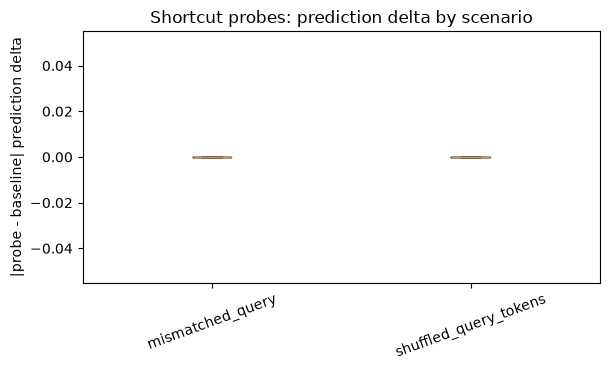

In [12]:
if shortcut_evidence["evidence_status"].eq("available").all():
    plot_scenario_prediction_deltas(
        shortcut_predictions, "Shortcut probes: prediction delta by scenario"
    )
else:
    print(
        "needs-new-evidence: shortcut delta plot requires persisted paired "
        "shortcut predictions"
    )

### Shortcut Test Decision

**Observation:** The preceding shortcut table uses only stored paired outcomes and otherwise renders the missing-evidence diagnostic.

**Interpretation:** Shortcut behavior cannot be inferred from a probe template, submission file, or model weight.

**Action:** Persist the scenario outputs named by the diagnostic before accepting or rejecting shortcut-risk hypotheses.

## 6. Error Slices and Failure Taxonomy

Calculate residual slices and a data-derived failure taxonomy from validated prediction rows.

In [13]:
if prediction_log is None:
    error_slice_evidence = needs_new_evidence(
        "error_slices",
        "validated labeled prediction_log",
        "needs-new-evidence: residual slices require the Section 1 contract",
    )
    failure_taxonomy_summary = None
else:
    residual_frame = prediction_log.assign(
        residual=prediction_log["y_true"] - prediction_log["y_pred"]
    )
    residual_frame["absolute_error"] = residual_frame["residual"].abs()
    residual_frame["description_presence"] = residual_frame["product_description"].ne(
        ""
    )
    residual_frame["query_length_bin"] = pd.cut(
        residual_frame["search_term"].str.len(), [0, 5, 15, 30, float("inf")]
    )
    residual_frame["relevance_band"] = pd.cut(
        residual_frame["y_true"], [0, 1.5, 2.5, float("inf")]
    )
    error_slice_evidence = pd.concat(
        [
            residual_frame.groupby(dimension, dropna=False)
            .agg(
                rows=("id", "size"),
                mae=("absolute_error", "mean"),
                rmse=("residual", lambda values: (values.pow(2).mean()) ** 0.5),
            )
            .reset_index()
            .assign(slice_dimension=dimension, evidence_status="available")
            for dimension in (
                "description_presence",
                "query_length_bin",
                "relevance_band",
                "split",
            )
        ],
        ignore_index=True,
    )
    failure_taxonomy_summary = (
        residual_frame.assign(
            failure_taxonomy=lambda frame: pd.Series("other", index=frame.index).mask(
                frame["absolute_error"].ge(frame["absolute_error"].quantile(0.9)),
                "high_absolute_error",
            )
        )
        .groupby("failure_taxonomy", dropna=False)
        .agg(rows=("id", "size"), mean_absolute_error=("absolute_error", "mean"))
        .reset_index()
    )
display(error_slice_evidence)
if prediction_log is not None:
    display(failure_taxonomy_summary)

,description_presence,rows,mae,rmse,slice_dimension,evidence_status,query_length_bin,relevance_band,split
0,True,14814,0.426674,0.520690,description_presence,available,NaN,NaN,NaN
1,NaN,290,0.587210,0.709897,query_length_bin,available,"(0.0, 5.0]",NaN,NaN
2,NaN,4883,0.454007,0.542624,query_length_bin,available,"(5.0, 15.0]",NaN,NaN
3,NaN,8443,0.411296,0.506367,query_length_bin,available,"(15.0, 30.0]",NaN,NaN
4,NaN,1198,0.384781,0.472619,query_length_bin,available,"(30.0, inf]",NaN,NaN
5,NaN,998,1.142147,1.159587,relevance_band,available,NaN,"(0.0, 1.5]",NaN
6,NaN,7000,0.304352,0.388728,relevance_band,available,NaN,"(1.5, 2.5]",NaN
7,NaN,6816,0.447538,0.487013,relevance_band,available,NaN,"(2.5, inf]",NaN
8,NaN,14814,0.426674,0.520690,split,available,NaN,NaN,validation


,failure_taxonomy,rows,mean_absolute_error
0,high_absolute_error,1482,1.045117
1,other,13332,0.357927


Visualize slice-level error structure: MAE per category for each computed
slice dimension (with per-slice row counts), and the residual spread per
relevance band. Skipped until the Section 1 contract passes.

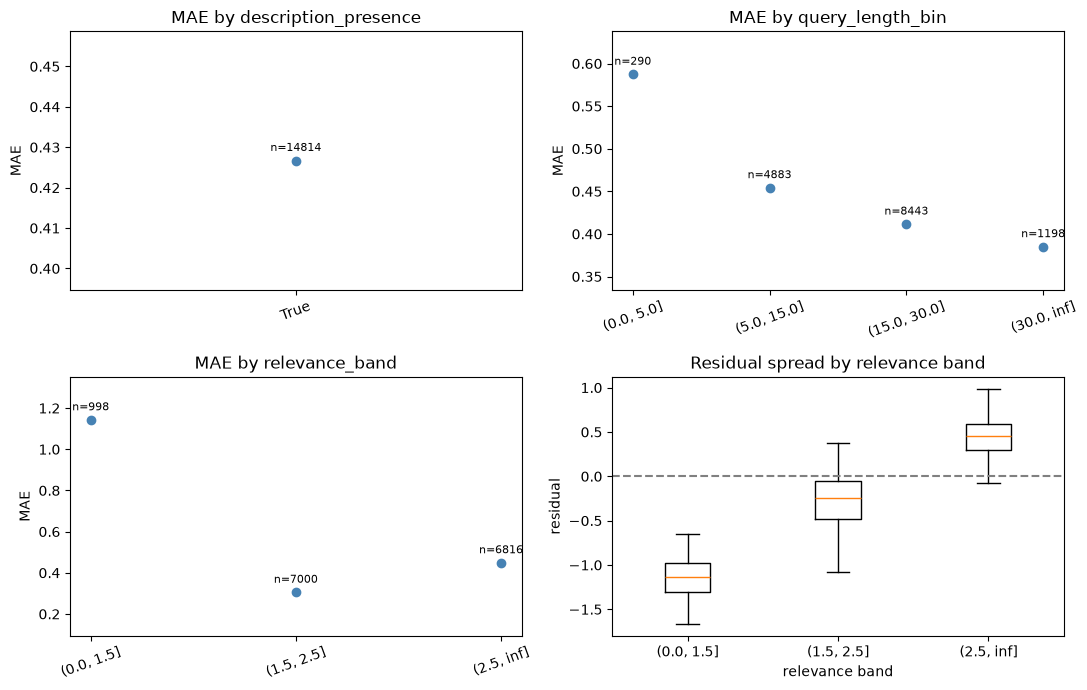

In [14]:
if prediction_log is None:
    print("needs-new-evidence: slice plots require the Section 1 contract")
else:
    slice_dimensions = ("description_presence", "query_length_bin", "relevance_band")
    fig, axes = plt.subplots(2, 2, figsize=(11, 7))
    for ax, dimension in zip(axes.ravel()[:3], slice_dimensions):
        dimension_slices = error_slice_evidence.loc[
            error_slice_evidence["slice_dimension"].eq(dimension)
        ]
        categories = dimension_slices[dimension].astype(str)
        ax.plot(
            categories,
            dimension_slices["mae"],
            marker="o",
            linestyle="",
            color="steelblue",
        )
        for category, mae_value, rows in zip(
            categories, dimension_slices["mae"], dimension_slices["rows"]
        ):
            ax.annotate(
                f"n={rows}",
                (category, mae_value),
                textcoords="offset points",
                xytext=(0, 7),
                ha="center",
                fontsize=8,
            )
        ax.margins(y=0.25)
        ax.set_ylabel("MAE")
        ax.set_title(f"MAE by {dimension}")
        ax.tick_params(axis="x", rotation=20)
    relevance_bands = residual_frame["relevance_band"].cat.categories
    residuals_by_band = [
        residual_frame.loc[
            residual_frame["relevance_band"].eq(band), "residual"
        ].to_numpy()
        for band in relevance_bands
    ]
    axes[1, 1].boxplot(
        residuals_by_band,
        tick_labels=[str(band) for band in relevance_bands],
        flierprops={"marker": ".", "markersize": 3, "alpha": 0.4},
    )
    axes[1, 1].axhline(0.0, color="gray", linestyle="--")
    axes[1, 1].set_xlabel("relevance band")
    axes[1, 1].set_ylabel("residual")
    axes[1, 1].set_title("Residual spread by relevance band")
    fig.tight_layout()
    plt.show()

### Error Slice Decision

**Observation:** The preceding slice table derives errors from the same validated labeled rows used for final performance.

**Interpretation:** The displayed slice dimensions identify where persisted residual evidence is strongest or absent.

**Action:** Investigate the largest displayed slice error, or satisfy the diagnostic before creating a failure taxonomy claim.

## 7. XAI and Explanation Validation

Summarize stored attribution faithfulness only when linked to validated prediction IDs.

In [15]:
stored_attributions, attribution_diagnostic = read_csv_or_diagnostic(
    "stored_attributions"
)
if prediction_log is None:
    xai_evidence = needs_new_evidence(
        "xai",
        "validated prediction_log",
        "needs-new-evidence: attribution linkage requires the Section 1 contract",
    )
elif stored_attributions is None:
    xai_evidence = needs_new_evidence(
        "xai", "stored_attributions", attribution_diagnostic or "needs-new-evidence"
    )
else:
    required_attribution_columns = {
        "id",
        "faithfulness_deletion_delta",
        *identity_columns,
    }
    missing_attribution_columns = required_attribution_columns - set(
        stored_attributions.columns
    )
    if missing_attribution_columns:
        xai_evidence = needs_new_evidence(
            "xai",
            "linked attribution columns",
            f"needs-new-evidence: missing columns {sorted(missing_attribution_columns)}",
        )
    elif not bool(stored_attributions["id"].isin(prediction_log["id"]).all()):
        xai_evidence = needs_new_evidence(
            "xai",
            "linked attribution IDs",
            "needs-new-evidence: stored attribution IDs are not all present in prediction_log",
        )
    elif any(
        not bool(stored_attributions[column].eq(inferred_identity[column]).all())
        for column in identity_columns
    ):
        xai_evidence = needs_new_evidence(
            "xai",
            "linked attribution identity",
            "needs-new-evidence: stored attribution identity does not match prediction_log",
        )
    else:
        faithfulness = stored_attributions["faithfulness_deletion_delta"]
        if (
            not pd.api.types.is_numeric_dtype(faithfulness)
            or not bool(faithfulness.notna().all())
            or bool(faithfulness.isin((float("inf"), float("-inf"))).any())
        ):
            xai_evidence = needs_new_evidence(
                "xai",
                "numeric faithfulness_deletion_delta",
                "needs-new-evidence: attribution faithfulness values must be numeric and non-null",
            )
        else:
            xai_evidence = pd.DataFrame(
                [
                    {
                        "evidence_status": "available",
                        "attribution_rows": len(stored_attributions),
                        "mean_faithfulness_deletion_delta": faithfulness.mean(),
                        "positive_faithfulness_rate": faithfulness.gt(0).mean(),
                    }
                ]
            )
display(xai_evidence)

,evidence_status,attribution_rows,mean_faithfulness_deletion_delta,positive_faithfulness_rate
0,available,200,0.001009,0.635


Visualize the linked attribution faithfulness distribution against the zero
no-effect boundary; mass right of zero supports explanation validity.
Skipped until stored attributions pass the linkage checks above.

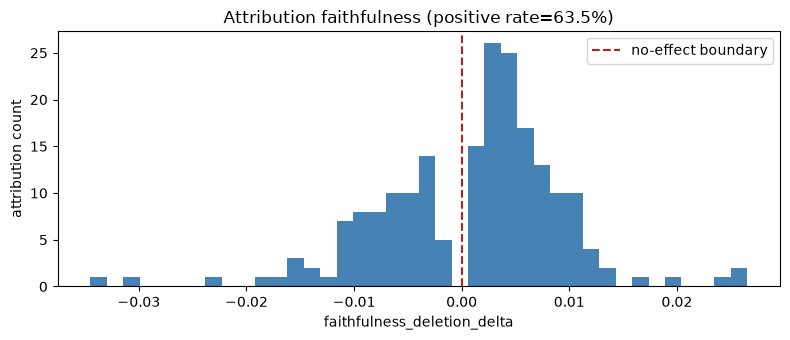

In [16]:
if xai_evidence["evidence_status"].eq("available").all():
    faithfulness_values = stored_attributions["faithfulness_deletion_delta"]
    positive_rate = float(faithfulness_values.gt(0).mean())
    fig, ax = plt.subplots(figsize=(8, 3.5))
    ax.hist(faithfulness_values, bins=40, color="steelblue")
    ax.axvline(0.0, color="firebrick", linestyle="--", label="no-effect boundary")
    ax.set_xlabel("faithfulness_deletion_delta")
    ax.set_ylabel("attribution count")
    ax.set_title(f"Attribution faithfulness (positive rate={positive_rate:.1%})")
    ax.legend()
    fig.tight_layout()
    plt.show()
else:
    print(
        "needs-new-evidence: faithfulness plot requires linked stored attributions"
    )

### Explanation Validity Decision

**Observation:** The preceding XAI evidence reports stored, linked faithfulness values or the exact linkage or quality gap.

**Interpretation:** Explanation validity depends on the displayed attribution rows and their linkage to evaluated predictions.

**Action:** Store or repair the attribution evidence named above before using explanations in a release decision.

## 8. Release Decision and Known Limitations

Derive the decision only from the displayed artifact-completeness status table.

In [17]:
release_artifact_status = artifact_inventory.assign(
    complete=artifact_inventory["status"].eq("available")
)
release_decision = (
    "submit"
    if bool(release_artifact_status["complete"].all())
    else "needs-new-evidence"
)
release_evidence = release_artifact_status.assign(release_decision=release_decision)
display(release_evidence)

,artifact,path,exists,status,release_required,complete,release_decision
0,prediction_log,results/prediction_log.csv,True,available,True,True,submit
1,artifact_manifest,results/artifact_manifest.json,True,available,True,True,submit
2,probe_predictions,results/probe_predictions.csv,True,available,True,True,submit
3,stress_probe_predictions,results/stress_probe_predictions.csv,True,available,True,True,submit
4,shortcut_probe_predictions,results/shortcut_probe_predictions.csv,True,available,True,True,submit
5,stored_attributions,results/stored_attributions.csv,True,available,True,True,submit


### Release Decision Record

**Observation:** The preceding release table derives its decision from the artifact-completeness status of every required persisted input.

**Interpretation:** An incomplete displayed inventory prevents a release decision based on evidence that is not yet stored.

**Action:** Resolve each displayed `needs-new-evidence` row, then rerun this audit to derive the next decision from the refreshed inventory.